#### ImageNet Adversarial Robustness Evaluation
## ECE6252 Course Project

**Models evaluated:**
- Standard ResNet-50 (no defence) — baseline
- Wong2020Fast (FGSM adversarial training) — RobustBench
- Engstrom2019Robustness (PGD adversarial training) — RobustBench
- Singh2023Revisiting (ConvNeXt-S, augmentation + architecture) — RobustBench
- Amini2024MeanSparse (MeanSparse, inference-time feature sparsification) — RobustBench

**Attacks / evaluations:**
- Clean (ImageNet val, 50k images)
- FGSM (ε=4/255)
- PGD-20 (ε=4/255, α=1/255, steps=20)
- AutoAttack (ε=4/255, 5000 images; 5 per class, all 1000 classes)
- ImageNet-A (naturally hard images, 200-class subset)

#### Cell 1 — Environment Setup (Run First Every Session)

In [1]:
import os
import tempfile

# This redirects all cache and temp files to scratch storage.
scratch = os.environ.get("SCRATCH", "/storage/ice1/2/8/amusleh3/hf_cache")
tmp = os.environ.get("SCRATCH_TMP", "/storage/ice1/2/8/amusleh3/tmp")

os.makedirs(scratch, exist_ok=True)
os.makedirs(tmp, exist_ok=True)

os.environ['HF_HOME'] = scratch # Hugging Face model/dataset cache
os.environ['HF_DATASETS_CACHE'] = scratch # Hugging Face datasets cache
os.environ['HUGGINGFACE_HUB_CACHE'] = scratch # Hugging Face hub cache
os.environ['TMPDIR'] = tmp # System temp directory
tempfile.tempdir = tmp # Python tempfile module

print("Scratch paths set successfully")
print(f"  HF_HOME : {os.environ['HF_HOME']}")
print(f"  HF_DATASETS_CACHE : {os.environ['HF_DATASETS_CACHE']}")
print(f"  TMPDIR : {os.environ['TMPDIR']}")

Scratch paths set successfully
  HF_HOME : /storage/ice1/2/8/amusleh3/hf_cache
  HF_DATASETS_CACHE : /storage/ice1/2/8/amusleh3/hf_cache
  TMPDIR : /storage/ice1/2/8/amusleh3/tmp


#### Cell 2 — Imports & Login

In [3]:
import torch
import json
import glob
import subprocess
from collections import defaultdict
from torchvision import transforms, datasets
import torchvision.models as models
from tqdm import tqdm
from datasets import load_dataset, concatenate_datasets, Dataset
from huggingface_hub import login
from robustbench.utils import load_model
import torchattacks
from autoattack import AutoAttack
import matplotlib.pyplot as plt
import numpy as np
import urllib.request
import pandas as pd

login(token=os.environ.get("HF_TOKEN")) # This is the Hugging Face auth token 
print("Imports complete")

Imports complete


#### Cell 3 — Transforms

**Important:** RobustBench models contain an internal `ImageNormalizer` layer hence use `transform_robustbench` for all RobustBench models.

In [4]:
# For standard torchvision models; normalisation applied externally
transform_standard = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# For RobustBench models; model normalises internally, so do not normalize here
transform_robustbench = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])

print("Transforms defined")
print(" - transform_standard: used for baseline_model")
print(" - transform_robustbench: used for fgsm_model, pgd_model, singh_model, meansparse_model  (all RobustBench)")

Transforms defined
 - transform_standard: used for baseline_model
 - transform_robustbench: used for fgsm_model, pgd_model, singh_model, meansparse_model  (all RobustBench)


#### Cell 4 — Load Models

In [5]:
# Standard undefended ResNet-50; no adversarial training
baseline_model = models.resnet50(
    weights=models.ResNet50_Weights.IMAGENET1K_V1
).cuda().eval()
print("Loaded: baseline_model (Standard ResNet-50)")

# FGSM adversarially trained ResNet-50; Wong et al. (2020)
fgsm_model = load_model(
    model_name='Wong2020Fast',
    dataset='imagenet',
    threat_model='Linf'
).cuda().eval()
print("Loaded: fgsm_model (Wong2020Fast)")

# PGD adversarially trained ResNet-50; Engstrom et al. (2019)
pgd_model = load_model(
    model_name='Engstrom2019Robustness',
    dataset='imagenet',
    threat_model='Linf'
).cuda().eval()
print("Loaded: pgd_model (Engstrom2019Robustness)")

# ConvNeXt-S with augmentation + architecture changes; Singh et al. (2023)
singh_model = load_model(
    model_name='Singh2023Revisiting_ConvNeXt-S-ConvStem',
    dataset='imagenet',
    threat_model='Linf'
).cuda().eval()
print("Loaded: singh_model (Singh2023Revisiting_ConvNeXt-S-ConvStem)")

# Inference-time feature sparsification on frozen Swin-L backbone; Amini et al. (2024)
meansparse_model = load_model(
    model_name='Amini2024MeanSparse_Swin-L',
    dataset='imagenet',
    threat_model='Linf'
).cuda().eval()
print("Loaded: meansparse_model (Amini2024MeanSparse_Swin-L)")

Loaded: baseline_model (Standard ResNet-50)
Loaded: fgsm_model (Wong2020Fast)
Loaded: pgd_model (Engstrom2019Robustness)
Loaded: singh_model (Singh2023Revisiting_ConvNeXt-S-ConvStem)
Loaded: meansparse_model (Amini2024MeanSparse_Swin-L)


#### Cell 5 — Evaluation Functions & Result Saving

In [6]:
# Results are saved to all_results.json after every evaluation.
# Safe to restart kernel mid-run; completed evaluations need not be re-run
# as long as all_results.json is present.

RESULTS_FILE = "all_results.json"

def load_results():
    """Load existing results from disk, or return empty dict."""
    if os.path.exists(RESULTS_FILE):
        with open(RESULTS_FILE, "r") as f:
            return json.load(f)
    return {}

def save_result(key, value):
    """Save a single result to disk immediately after each evaluation."""
    results = load_results()
    results[key] = value
    with open(RESULTS_FILE, "w") as f:
        json.dump(results, f, indent=4)
    print(f"  Saved: {key} = {value:.2f}%")


def get_dataset():
    # Loads ImageNet val from locally cached Arrow shards; this is faster than streaming.
    # Set IMAGENET_ARROW_DIR to the local cache path, or update the fallback below.
    arrow_dir = os.environ.get("IMAGENET_ARROW_DIR", "/storage/ice1/2/8/amusleh3/hf_cache/ILSVRC___imagenet-1k/default-40ca9052ea87658b/0.0.0/49e2ee26f3810fb5a7536bbf732a7b07389a47b5")
    arrow_files = sorted(glob.glob(os.path.join(arrow_dir, "imagenet-1k-validation-*.arrow")))
    print(f"  Loading {len(arrow_files)} Arrow shards")
    return concatenate_datasets([Dataset.from_file(f) for f in arrow_files])

def evaluate_clean(model, transform, label, device='cuda', max_samples=50000):
    """Evaluate model on clean unperturbed ImageNet validation images."""
    ds = get_dataset()
    model.eval()
    correct = 0
    total = 0
    for sample in tqdm(ds, total=max_samples):
        img = transform(sample['image'].convert('RGB')).unsqueeze(0).to(device)
        lbl = torch.tensor([sample['label']]).to(device)
        with torch.no_grad():
            pred = model(img).argmax(dim=1)
        correct += (pred == lbl).sum().item()
        total += 1
        if total >= max_samples:
            break
    acc = correct / total * 100
    print(f"Clean accuracy [{label}]: {acc:.2f}% ({correct}/{total})")
    save_result(label, acc)
    return acc

def evaluate_adversarial(model, transform, attack, label, device='cuda', max_samples=50000):
    """Evaluate model on adversarially perturbed ImageNet validation images."""
    ds = get_dataset()
    model.eval()
    correct = 0
    total = 0
    for sample in tqdm(ds, total=max_samples):
        img = transform(sample['image'].convert('RGB')).unsqueeze(0).to(device)
        lbl = torch.tensor([sample['label']]).to(device)
        adv_img = attack(img, lbl)
        with torch.no_grad():
            pred = model(adv_img).argmax(dim=1)
        correct += (pred == lbl).sum().item()
        total += 1
        if total >= max_samples:
            break
    acc = correct / total * 100
    print(f"Adversarial accuracy [{label}]: {acc:.2f}% ({correct}/{total})")
    save_result(label, acc)
    return acc

def collect_balanced_subset(transform, n_per_class=5, n_classes=1000):
    """Collect n_per_class images from each of n_classes for AutoAttack evaluation."""
    ds = get_dataset()
    class_buckets = defaultdict(list)
    print(f"Collecting {n_per_class} images per class ({n_per_class * n_classes} total)...")
    for sample in tqdm(ds):
        label = sample['label']
        if len(class_buckets[label]) < n_per_class:
            img = transform(sample['image'].convert('RGB'))
            class_buckets[label].append(img)
        if (len(class_buckets) == n_classes and
                all(len(v) == n_per_class for v in class_buckets.values())):
            break
    all_imgs, all_labels = [], []
    for lbl, imgs in class_buckets.items():
        all_imgs.extend(imgs)
        all_labels.extend([lbl] * len(imgs))
    x = torch.stack(all_imgs).cuda()
    y = torch.tensor(all_labels).cuda()
    print(f"Collected {len(all_imgs)} images across {len(class_buckets)} classes")
    return x, y

def evaluate_autoattack(model, transform, label, device='cuda'):
    """Run AutoAttack on balanced 5000-image subset (5 per class, all 1000 classes)."""
    x_test, y_test = collect_balanced_subset(transform)
    adversary = AutoAttack(model, norm='Linf', eps=4/255, version='standard')
    x_adv = adversary.run_standard_evaluation(x_test, y_test, bs=128)
    with torch.no_grad():
        preds = model(x_adv).argmax(dim=1)
    acc = (preds == y_test).float().mean().item() * 100
    print(f"AutoAttack accuracy [{label}]: {acc:.2f}%")
    save_result(label, acc)
    return acc

# Download ImageNet class index mapping; this is only needed once
if not os.path.exists("imagenet_class_index.json"):
    urllib.request.urlretrieve(
        "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json",
        "imagenet_class_index.json"
    )

def evaluate_imagenet_a(model, transform, label, device='cuda'):
    """Evaluate model on ImageNet-A (naturally hard images, 200-class subset).
    Downloads ImageNet-A if not already present. Remaps folder indices (0-199)
    to full ImageNet class indices using WordNet ID mapping."""
    if not os.path.exists("imagenet-a"):
        print("Downloading ImageNet-A...")
        subprocess.run(["wget", "-q",
            "https://people.eecs.berkeley.edu/~hendrycks/imagenet-a.tar",
            "-O", "imagenet-a.tar"])
        subprocess.run(["tar", "-xf", "imagenet-a.tar"])

    # Build WordNet ID -> ImageNet class index mapping
    with open("imagenet_class_index.json") as f:
        class_idx = json.load(f)
    wnid_to_imagenet_idx = {v[0]: int(k) for k, v in class_idx.items()}

    dataset = datasets.ImageFolder("imagenet-a", transform=transform)
    loader = torch.utils.data.DataLoader(dataset, batch_size=64,
                                          num_workers=4, pin_memory=True)

    # Remap folder indices (0-199) to actual ImageNet class indices
    remap = torch.tensor(
        [wnid_to_imagenet_idx[cls] for cls in dataset.classes]
    ).to(device)

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in tqdm(loader):
            imgs = imgs.to(device)
            labels = labels.to(device)
            remapped_labels = remap[labels]
            preds = model(imgs).argmax(dim=1)
            correct += (preds == remapped_labels).sum().item()
            total += labels.size(0)

    acc = correct / total * 100
    print(f"ImageNet-A accuracy [{label}]: {acc:.2f}% ({correct}/{total})")
    save_result(label, acc)
    return acc

## Clean Accuracy Evaluations

Evaluate all five models on unperturbed ImageNet validation images.

In [6]:
# Clean — Standard ResNet-50
standard_clean_acc = evaluate_clean(
    baseline_model, transform_standard,
    label="standard_clean_acc"
)

100%|█████████▉| 49999/50000 [08:38<00:00, 96.40it/s] 


Clean accuracy [standard_clean_acc]: 76.14% (38071/50000)
  Saved: standard_clean_acc = 76.14%


In [7]:
# Clean — Wong2020Fast (FGSM adversarial training)
fgsm_clean_acc = evaluate_clean(
    fgsm_model, transform_robustbench,
    label="fgsm_clean_acc"
)

100%|█████████▉| 49999/50000 [07:54<00:00, 105.39it/s]

Clean accuracy [fgsm_clean_acc]: 53.81% (26903/50000)
  Saved: fgsm_clean_acc = 53.81%


In [8]:
# Clean — Engstrom2019 (PGD adversarial training)
pgd_clean_acc = evaluate_clean(
    pgd_model, transform_robustbench,
    label="pgd_clean_acc"
)

100%|█████████▉| 49999/50000 [07:43<00:00, 107.93it/s]

Clean accuracy [pgd_clean_acc]: 62.40% (31202/50000)
  Saved: pgd_clean_acc = 62.40%


In [28]:
# Clean — Singh2023 (augmentation + architecture)
print("Evaluating: Clean (ImageNet val)...")
singh_clean_acc = evaluate_clean(
    singh_model, transform_robustbench,
    label="singh_clean_acc"
)

Evaluating: Clean (ImageNet val)...


100%|█████████▉| 49999/50000 [10:11<00:00, 81.82it/s] 

Clean accuracy [singh_clean_acc]: 73.36% (36682/50000)
  Saved: singh_clean_acc = 73.36%


In [33]:
# Clean — MeanSparse (inference-time sparsification)
print("Evaluating: Clean (ImageNet val)...")
meansparse_clean_acc = evaluate_clean(
    meansparse_model, transform_robustbench,
    label="meansparse_clean_acc"
)

Evaluating: Clean (ImageNet val)...


100%|█████████▉| 49999/50000 [24:31<00:00, 33.97it/s]


Clean accuracy [meansparse_clean_acc]: 78.05% (39026/50000)
  Saved: meansparse_clean_acc = 78.05%


## FGSM Attack Evaluations (ε=4/255)

Single-step gradient sign attack. Off-diagonal cells test cross-generalisation.

In [9]:
# FGSM attack — Standard ResNet-50 (no defence)
fgsm_attack_baseline = torchattacks.FGSM(baseline_model, eps=4/255)
standard_fgsm_acc = evaluate_adversarial(
    baseline_model, transform_standard, fgsm_attack_baseline,
    label="standard_fgsm_acc"
)

100%|█████████▉| 49999/50000 [18:06<00:00, 46.02it/s]

Adversarial accuracy [standard_fgsm_acc]: 27.40% (13702/50000)
  Saved: standard_fgsm_acc = 27.40%


In [10]:
# FGSM attack — Wong2020Fast (FGSM AT) — within-defence test
fgsm_attack_fgsm = torchattacks.FGSM(fgsm_model, eps=4/255)
fgsm_fgsm_acc = evaluate_adversarial(
    fgsm_model, transform_robustbench, fgsm_attack_fgsm,
    label="fgsm_fgsm_acc"
)

100%|█████████▉| 49999/50000 [17:23<00:00, 47.92it/s]


Adversarial accuracy [fgsm_fgsm_acc]: 32.69% (16346/50000)
  Saved: fgsm_fgsm_acc = 32.69%


In [11]:
# FGSM attack — Engstrom2019 (PGD AT) — cross-generalisation test
fgsm_attack_pgd = torchattacks.FGSM(pgd_model, eps=4/255)
pgd_fgsm_acc = evaluate_adversarial(
    pgd_model, transform_robustbench, fgsm_attack_pgd,
    label="pgd_fgsm_acc"
)

100%|█████████▉| 49999/50000 [16:12<00:00, 51.40it/s]


Adversarial accuracy [pgd_fgsm_acc]: 39.73% (19863/50000)
  Saved: pgd_fgsm_acc = 39.73%


In [30]:
# FGSM — Singh2023 (augmentation + architecture) - cross-generalisation test
print("Evaluating: FGSM (eps=4/255)...")
fgsm_attack_singh = torchattacks.FGSM(singh_model, eps=4/255)
singh_fgsm_acc = evaluate_adversarial(
    singh_model, transform_robustbench, fgsm_attack_singh,
    label="singh_fgsm_acc"
)

Evaluating: FGSM (eps=4/255)...


100%|█████████▉| 49999/50000 [21:06<00:00, 39.46it/s]

Adversarial accuracy [singh_fgsm_acc]: 55.55% (27775/50000)
  Saved: singh_fgsm_acc = 55.55%


In [36]:
# FGSM — MeanSparse (inference-time sparsification) - cross-generalisation test
print("Evaluating: FGSM (eps=4/255)...")
fgsm_attack_meansparse = torchattacks.FGSM(meansparse_model, eps=4/255)
meansparse_fgsm_acc = evaluate_adversarial(
    meansparse_model, transform_robustbench, fgsm_attack_meansparse,
    label="meansparse_fgsm_acc"
)

Evaluating: FGSM (eps=4/255)...


100%|█████████▉| 49999/50000 [58:00<00:00, 14.37it/s]  


Adversarial accuracy [meansparse_fgsm_acc]: 66.18% (33091/50000)
  Saved: meansparse_fgsm_acc = 66.18%


## PGD Attack Evaluations (ε=4/255, α=1/255, steps=20)

Iterative attack, stronger than FGSM.

In [6]:
# PGD attack — Standard ResNet-50 (no defence)
pgd_attack_baseline = torchattacks.PGD(baseline_model, eps=4/255, alpha=1/255, steps=20)
standard_pgd_acc = evaluate_adversarial(
    baseline_model, transform_standard, pgd_attack_baseline,
    label="standard_pgd_acc"
)

100%|█████████▉| 49999/50000 [1:53:02<00:00,  7.37it/s]  

Adversarial accuracy [standard_pgd_acc]: 1.14% (568/50000)
  Saved: standard_pgd_acc = 1.14%


In [6]:
# PGD attack — Wong2020Fast (FGSM AT) — cross-generalisation test
pgd_attack_fgsm = torchattacks.PGD(fgsm_model, eps=4/255, alpha=1/255, steps=20)
fgsm_pgd_acc = evaluate_adversarial(
    fgsm_model, transform_robustbench, pgd_attack_fgsm,
    label="fgsm_pgd_acc"
)

100%|█████████▉| 49999/50000 [1:54:31<00:00,  7.28it/s]  

Adversarial accuracy [fgsm_pgd_acc]: 27.88% (13941/50000)
  Saved: fgsm_pgd_acc = 27.88%


In [6]:
# PGD attack — Engstrom2019 (PGD AT) — within-defence test
pgd_attack_pgd = torchattacks.PGD(pgd_model, eps=4/255, alpha=1/255, steps=20)
pgd_pgd_acc = evaluate_adversarial(
    pgd_model, transform_robustbench, pgd_attack_pgd,
    label="pgd_pgd_acc"
)

100%|█████████▉| 49999/50000 [1:58:45<00:00,  7.02it/s]  

Adversarial accuracy [pgd_pgd_acc]: 33.22% (16609/50000)
  Saved: pgd_pgd_acc = 33.22%


In [35]:
# PGD — Singh2023 (augmentation + architecture) - cross-generalisation test
print("Evaluating: PGD (eps=4/255, steps=20)...")
pgd_attack_singh = torchattacks.PGD(singh_model, eps=4/255, alpha=1/255, steps=20)
singh_pgd_acc = evaluate_adversarial(
    singh_model, transform_robustbench, pgd_attack_singh,
    label="singh_pgd_acc"
)

Evaluating: PGD (eps=4/255, steps=20)...


100%|█████████▉| 49999/50000 [3:41:35<00:00,  3.76it/s]  

Adversarial accuracy [singh_pgd_acc]: 52.77% (26385/50000)
  Saved: singh_pgd_acc = 52.77%


In [8]:
# PGD — MeanSparse (inference-time sparsification) - cross-generalisation test
# Resumable evaluation; checkpoints every 500 samples to handle session timeouts.
CKPT_PATH = os.environ.get("CKPT_PATH", "/storage/ice1/2/8/amusleh3/tmp/ckpt_meansparse_pgd.pt")

def evaluate_adversarial_resumable(model, transform, attack, label, device='cuda', max_samples=50000, checkpoint_every=500):
    """Resumable adversarial evaluation with checkpoint support.
    Saves progress to CKPT_PATH every checkpoint_every samples.
    On restart, skips already-processed samples and resumes from last checkpoint.
    Checkpoint is deleted on successful completion."""
    # Resume or start fresh
    if os.path.exists(CKPT_PATH):
        with open(CKPT_PATH) as f:
            ckpt = json.load(f)
        start = ckpt['total']
        correct = ckpt['correct']
        total = ckpt['total']
        print(f"  Resuming [{label}] from sample {start}/{max_samples} "
              f"(running acc: {correct/total*100:.2f}%)")
    else:
        start, correct, total = 0, 0, 0
        print(f"  Starting [{label}] from scratch")

    # Load dataset and skip already-processed samples 
    ds = get_dataset()
    model.eval()

    for i, sample in enumerate(tqdm(ds, total=max_samples)):
        if i < start:
            continue
        if i >= max_samples:
            break

        img = transform(sample['image'].convert('RGB')).unsqueeze(0).to(device)
        lbl = torch.tensor([sample['label']]).to(device)
        adv_img = attack(img, lbl)
        with torch.no_grad():
            pred = model(adv_img).argmax(dim=1)
        correct += (pred == lbl).sum().item()
        total += 1

        # Save checkpoint 
        if total % checkpoint_every == 0:
            with open(CKPT_PATH, 'w') as f:
                json.dump({'correct': correct, 'total': total}, f)
            print(f"  Checkpoint saved: {total}/{max_samples}, "
                  f"running acc: {correct/total*100:.2f}%")

    acc = correct / total * 100
    print(f"Adversarial accuracy [{label}]: {acc:.2f}% ({correct}/{total})")
    save_result(label, acc)

    # Clean up checkpoint on successful completion
    if os.path.exists(CKPT_PATH):
        os.remove(CKPT_PATH)

    return acc

# Initialise PGD attack and run resumable evaluation on MeanSparse
print("Evaluating: PGD (eps=4/255, steps=20)...")
pgd_attack_meansparse = torchattacks.PGD(
    meansparse_model, eps=4/255, alpha=1/255, steps=20
)
meansparse_pgd_acc = evaluate_adversarial_resumable(
    meansparse_model, transform_robustbench, pgd_attack_meansparse,
    label="meansparse_pgd_acc"
)

Evaluating: PGD (eps=4/255, steps=20)...
  Resuming [meansparse_pgd_acc] from sample 45000/50000 (running acc: 62.78%)
  Loading 12 Arrow shards


 91%|█████████ | 45500/50000 [10:06<1:04:37,  1.16it/s]

  Checkpoint saved: 45500/50000, running acc: 62.76%


 92%|█████████▏| 46000/50000 [17:15<56:56,  1.17it/s]  

  Checkpoint saved: 46000/50000, running acc: 62.76%


...

  Checkpoint saved: 49000/50000, running acc: 62.76%


 99%|█████████▉| 49500/50000 [1:06:52<06:47,  1.23it/s]

  Checkpoint saved: 49500/50000, running acc: 62.80%


100%|██████████| 50000/50000 [1:13:38<00:00, 11.32it/s]

  Checkpoint saved: 50000/50000, running acc: 62.85%
Adversarial accuracy [meansparse_pgd_acc]: 62.85% (31425/50000)
  Saved: meansparse_pgd_acc = 62.85%


## AutoAttack Evaluations (ε=4/255)

Rigorous independent benchmark: APGD-CE + APGD-DLR + FAB + Square (black-box).
Evaluated on 5000 balanced images (5 per class, all 1000 classes).

In [7]:
# AutoAttack Tensor Collection 
# Collects a balanced 5000-image subset (5 per class, all 1000 classes) and saves pre-processed tensors to disk. 
# Two versions are saved — one with external normalisation (baseline) and one without (RobustBench models)
# to avoid reprocessing during AutoAttack evaluation.

SAVE_DIR = os.environ.get("SAVE_DIR", "/storage/ice1/2/8/amusleh3/autoattack_tensors")
os.makedirs(SAVE_DIR, exist_ok=True)

print("Collecting balanced subset with transform_standard...")
x_standard, y_test = collect_balanced_subset(transform_standard)
torch.save(x_standard, f"{SAVE_DIR}/x_standard_5000.pt")
torch.save(y_test, f"{SAVE_DIR}/y_test_5000.pt")
print("Saved x_standard and y_test")

print("Collecting balanced subset with transform_robustbench...")
x_robustbench, _ = collect_balanced_subset(transform_robustbench)
torch.save(x_robustbench, f"{SAVE_DIR}/x_robustbench_5000.pt")
print("Saved x_robustbench")

# Verify files saved correctly
for fname in ["x_standard_5000.pt", "y_test_5000.pt", "x_robustbench_5000.pt"]:
    size = os.path.getsize(os.path.join(SAVE_DIR, fname)) / 1e6
    print(f"  {fname}: {size:.1f} MB")

 25%|██▌       | 12636/50000 [01:05<03:13, 193.09it/s]


Collected 5000 images across 1000 classes
Saved x_standard and y_test


 25%|██▌       | 12636/50000 [00:40<02:01, 308.60it/s]


Collected 5000 images across 1000 classes
Saved x_robustbench
  x_standard_5000.pt: 3010.6 MB
  y_test_5000.pt: 0.0 MB
  x_robustbench_5000.pt: 3010.6 MB


In [8]:
# AutoAttack — Standard ResNet-50 (no defence)
x_standard = torch.load(f"{SAVE_DIR}/x_standard_5000.pt").cuda()
y_test = torch.load(f"{SAVE_DIR}/y_test_5000.pt").cuda()

print("=== Standard ResNet-50 | AutoAttack (ε=4/255) ===")
adversary = AutoAttack(baseline_model, norm='Linf', eps=4/255, version='standard')
x_adv = adversary.run_standard_evaluation(x_standard, y_test, bs=128)
with torch.no_grad():
    preds = baseline_model(x_adv).argmax(dim=1)
standard_autoattack_acc = (preds == y_test).float().mean().item() * 100
print(f"AutoAttack accuracy: {standard_autoattack_acc:.2f}%")
save_result("standard_autoattack_acc", standard_autoattack_acc)

=== Standard ResNet-50 | AutoAttack (ε=4/255) ===
setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 76.68%
apgd-ce - 1/30 - 127 out of 128 successfully perturbed
apgd-ce - 2/30 - 126 out of 128 successfully perturbed
apgd-ce - 3/30 - 124 out of 128 successfully perturbed
apgd-ce - 4/30 - 127 out of 128 successfully perturbed
apgd-ce - 5/30 - 127 out of 128 successfully perturbed
apgd-ce - 6/30 - 127 out of 128 successfully perturbed
apgd-ce - 7/30 - 128 out of 128 successfully perturbed
apgd-ce - 8/30 - 127 out of 128 successfully perturbed
apgd-ce - 9/30 - 128 out of 128 successfully perturbed
apgd-ce - 10/30 - 127 out of 128 successfully perturbed
apgd-ce - 11/30 - 126 out of 128 successfully perturbed
apgd-ce - 12/30 - 128 out of 128 successfully perturbed
apgd-ce - 13/30 - 127 out of 128 successfully perturbed
apgd-ce - 14/30 - 125 out of 128 successfully perturbed
apgd-ce - 15/30 - 127 out of 128 successfully

In [9]:
# AutoAttack — Wong2020Fast (FGSM AT)
x_robustbench = torch.load(f"{SAVE_DIR}/x_robustbench_5000.pt").cuda()
y_test = torch.load(f"{SAVE_DIR}/y_test_5000.pt").cuda()

print("=== Wong2020Fast (FGSM AT) | AutoAttack (ε=4/255) ===")
adversary = AutoAttack(fgsm_model, norm='Linf', eps=4/255, version='standard')
x_adv = adversary.run_standard_evaluation(x_robustbench, y_test, bs=128)
with torch.no_grad():
    preds = fgsm_model(x_adv).argmax(dim=1)
fgsm_autoattack_acc = (preds == y_test).float().mean().item() * 100
print(f"AutoAttack accuracy: {fgsm_autoattack_acc:.2f}%")
save_result("fgsm_autoattack_acc", fgsm_autoattack_acc)

=== Wong2020Fast (FGSM AT) | AutoAttack (ε=4/255) ===
setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 54.30%
apgd-ce - 1/22 - 60 out of 128 successfully perturbed
apgd-ce - 2/22 - 71 out of 128 successfully perturbed
apgd-ce - 3/22 - 79 out of 128 successfully perturbed
apgd-ce - 4/22 - 69 out of 128 successfully perturbed
apgd-ce - 5/22 - 58 out of 128 successfully perturbed
apgd-ce - 6/22 - 66 out of 128 successfully perturbed
apgd-ce - 7/22 - 57 out of 128 successfully perturbed
apgd-ce - 8/22 - 60 out of 128 successfully perturbed
apgd-ce - 9/22 - 61 out of 128 successfully perturbed
apgd-ce - 10/22 - 66 out of 128 successfully perturbed
apgd-ce - 11/22 - 59 out of 128 successfully perturbed
apgd-ce - 12/22 - 63 out of 128 successfully perturbed
apgd-ce - 13/22 - 56 out of 128 successfully perturbed
apgd-ce - 14/22 - 75 out of 128 successfully perturbed
apgd-ce - 15/22 - 55 out of 128 successfully perturbed


In [10]:
# AutoAttack — Engstrom2019 (PGD AT) — cross-generalisation test
x_robustbench = torch.load(f"{SAVE_DIR}/x_robustbench_5000.pt").cuda()
y_test = torch.load(f"{SAVE_DIR}/y_test_5000.pt").cuda()

print("=== Engstrom2019 (PGD AT) | AutoAttack (ε=4/255) ===")
adversary = AutoAttack(pgd_model, norm='Linf', eps=4/255, version='standard')
x_adv = adversary.run_standard_evaluation(x_robustbench, y_test, bs=128)
with torch.no_grad():
    preds = pgd_model(x_adv).argmax(dim=1)
pgd_autoattack_acc = (preds == y_test).float().mean().item() * 100
print(f"AutoAttack accuracy: {pgd_autoattack_acc:.2f}%")
save_result("pgd_autoattack_acc", pgd_autoattack_acc)

=== Engstrom2019 (PGD AT) | AutoAttack (ε=4/255) ===
setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 63.06%
apgd-ce - 1/25 - 61 out of 128 successfully perturbed
apgd-ce - 2/25 - 56 out of 128 successfully perturbed
apgd-ce - 3/25 - 76 out of 128 successfully perturbed
apgd-ce - 4/25 - 73 out of 128 successfully perturbed
apgd-ce - 5/25 - 61 out of 128 successfully perturbed
apgd-ce - 6/25 - 59 out of 128 successfully perturbed
apgd-ce - 7/25 - 68 out of 128 successfully perturbed
apgd-ce - 8/25 - 57 out of 128 successfully perturbed
apgd-ce - 9/25 - 62 out of 128 successfully perturbed
apgd-ce - 10/25 - 61 out of 128 successfully perturbed
apgd-ce - 11/25 - 61 out of 128 successfully perturbed
apgd-ce - 12/25 - 64 out of 128 successfully perturbed
apgd-ce - 13/25 - 56 out of 128 successfully perturbed
apgd-ce - 14/25 - 72 out of 128 successfully perturbed
apgd-ce - 15/25 - 59 out of 128 successfully perturbed
a

In [31]:
# AutoAttack — Singh2023 (augmentation + architecture)
print("Evaluating: AutoAttack (eps=4/255)...")
singh_autoattack_acc = evaluate_autoattack(
    singh_model, transform_robustbench,
    label="singh_autoattack_acc"
)

Evaluating: AutoAttack (eps=4/255)...


 25%|██▌       | 12636/50000 [01:06<03:15, 190.90it/s]


Collected 5000 images across 1000 classes
setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 73.60%
apgd-ce - 1/29 - 36 out of 128 successfully perturbed
apgd-ce - 2/29 - 37 out of 128 successfully perturbed
apgd-ce - 3/29 - 32 out of 128 successfully perturbed
apgd-ce - 4/29 - 34 out of 128 successfully perturbed
apgd-ce - 5/29 - 44 out of 128 successfully perturbed
apgd-ce - 6/29 - 30 out of 128 successfully perturbed
apgd-ce - 7/29 - 39 out of 128 successfully perturbed
apgd-ce - 8/29 - 35 out of 128 successfully perturbed
apgd-ce - 9/29 - 32 out of 128 successfully perturbed
apgd-ce - 10/29 - 32 out of 128 successfully perturbed
apgd-ce - 11/29 - 39 out of 128 successfully perturbed
apgd-ce - 12/29 - 41 out of 128 successfully perturbed
apgd-ce - 13/29 - 37 out of 128 successfully perturbed
apgd-ce - 14/29 - 39 out of 128 successfully perturbed
apgd-ce - 15/29 - 32 out of 128 successfully perturbed
apgd-ce - 16

**AutoAttack — MeanSparse (inference-time sparsification)**  
Chunked resumable evaluation — AutoAttack is re-initialised per chunk to allow checkpointing.
Tensors pre-collected in the collection cell above are reused here for consistency across models.

In [6]:
# AutoAttack — MeanSparse (inference-time sparsification)
checkpoint_path = f"{SAVE_DIR}/meansparse_autoattack_checkpoint.pt"
final_adv_path  = f"{SAVE_DIR}/meansparse_xadv.pt"

print("Checkpoint path:", checkpoint_path)
print("Final adversarial tensor path:", final_adv_path)

Checkpoint path: /storage/ice1/2/8/amusleh3/autoattack_tensors/meansparse_autoattack_checkpoint.pt
Final adversarial tensor path: /storage/ice1/2/8/amusleh3/autoattack_tensors/meansparse_xadv.pt


In [7]:
# Load pre-collected balanced subset; reuses tensors from collection cell for consistency
x_robustbench = torch.load(f"{SAVE_DIR}/x_robustbench_5000.pt").cuda()
y_test = torch.load(f"{SAVE_DIR}/y_test_5000.pt").cuda()

print("x_robustbench shape:", x_robustbench.shape)
print("y_test shape:", y_test.shape)

x_robustbench shape: torch.Size([5000, 3, 224, 224])
y_test shape: torch.Size([5000])


In [8]:
# Resume from checkpoint if available, otherwise start fresh
n = len(y_test)

if os.path.exists(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location="cpu")
    start_idx = ckpt["start_idx"]
    correct_mask = ckpt["correct_mask"]
    x_adv_chunks = ckpt["x_adv_chunks"]
    print(f"Resuming from index {start_idx} / {n}")
else:
    start_idx = 0
    correct_mask = torch.full((n,), False, dtype=torch.bool)
    x_adv_chunks = []
    print(f"Starting from scratch on {n} samples")

Resuming from index 4608 / 5000


In [12]:
# Run AutoAttack in chunks of 128 — re-initialised per chunk to allow checkpointing
meansparse_model.eval()
meansparse_model.cuda()

chunk_size = 128

for i in range(start_idx, n, chunk_size):
    end = min(i + chunk_size, n)

    x_chunk = x_robustbench[i:end]
    y_chunk = y_test[i:end]

    print(f"\n=== MeanSparse | AutoAttack | samples {i}:{end} ===")

    adversary = AutoAttack(
        meansparse_model,
        norm='Linf',
        eps=4/255,
        version='standard',
        device='cuda'
    )

    x_adv_chunk = adversary.run_standard_evaluation(x_chunk, y_chunk, bs=len(x_chunk))

    with torch.no_grad():
        preds = meansparse_model(x_adv_chunk).argmax(dim=1)
        chunk_correct = (preds == y_chunk).detach().cpu()

    correct_mask[i:end] = chunk_correct
    x_adv_chunks.append(x_adv_chunk.detach().cpu())
    # Save checkpoint after every chunk
    torch.save({
        "start_idx": end,
        "correct_mask": correct_mask,
        "x_adv_chunks": x_adv_chunks
    }, checkpoint_path)

    current_acc = correct_mask[:end].float().mean().item() * 100
    print(f"Saved checkpoint through sample {end}")
    print(f"Running robust accuracy so far: {current_acc:.2f}%")


=== MeanSparse | AutoAttack | samples 4608:4736 ===
setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 73.44%
apgd-ce - 1/1 - 19 out of 94 successfully perturbed
robust accuracy after APGD-CE: 58.59% (total time 20.5 s)
apgd-t - 1/1 - 0 out of 75 successfully perturbed
robust accuracy after APGD-T: 58.59% (total time 168.2 s)
fab-t - 1/1 - 0 out of 75 successfully perturbed
robust accuracy after FAB-T: 58.59% (total time 449.8 s)
square - 1/1 - 0 out of 75 successfully perturbed
robust accuracy after SQUARE: 58.59% (total time 904.0 s)
max Linf perturbation: 0.01569, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 58.59%
Saved checkpoint through sample 4736
Running robust accuracy so far: 60.18%

=== MeanSparse | AutoAttack | samples 4736:4864 ===
setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 74.22%
apgd-ce - 1/1 - 19 out of

In [13]:
# Reconstruct x_adv in order
x_adv_full = torch.cat(x_adv_chunks, dim=0)
torch.save(x_adv_full, final_adv_path)

meansparse_autoattack_acc = correct_mask.float().mean().item() * 100
print(f"\nFinal AutoAttack accuracy [meansparse_autoattack_acc]: {meansparse_autoattack_acc:.2f}%")

save_result("meansparse_autoattack_acc", meansparse_autoattack_acc)


Final AutoAttack accuracy [meansparse_autoattack_acc]: 60.26%
  Saved: meansparse_autoattack_acc = 60.26%


### ImageNet-A Evaluations (Natural Distribution Shift)

No synthetic attack; naturally hard images that fool models but not humans.
Tests whether robustness generalises beyond synthetic perturbations.
Class index remapping required: ImageNet-A covers 200 of 1000 ImageNet classes.

In [13]:
# ImageNet-A — Standard ResNet-50 (no defence)
standard_imagenet_a_acc = evaluate_imagenet_a(
    baseline_model, transform_standard,
    label="standard_imagenet_a_acc"
)

100%|██████████| 118/118 [00:10<00:00, 10.87it/s]

ImageNet-A accuracy [standard_imagenet_a_acc]: 0.00% (0/7500)
  Saved: standard_imagenet_a_acc = 0.00%


In [14]:
# ImageNet-A — Wong2020Fast (FGSM AT)
fgsm_imagenet_a_acc = evaluate_imagenet_a(
    fgsm_model, transform_robustbench,
    label="fgsm_imagenet_a_acc"
)

100%|██████████| 118/118 [00:09<00:00, 13.06it/s]

ImageNet-A accuracy [fgsm_imagenet_a_acc]: 0.53% (40/7500)
  Saved: fgsm_imagenet_a_acc = 0.53%


In [15]:
# ImageNet-A — Engstrom2019 (PGD AT)
pgd_imagenet_a_acc = evaluate_imagenet_a(
    pgd_model, transform_robustbench,
    label="pgd_imagenet_a_acc"
)

100%|██████████| 118/118 [00:09<00:00, 12.72it/s]

ImageNet-A accuracy [pgd_imagenet_a_acc]: 0.65% (49/7500)
  Saved: pgd_imagenet_a_acc = 0.65%


In [29]:
# ImageNet-A — Singh2023 (augmentation + architecture)
print("Evaluating: ImageNet-A (natural)...")
singh_imagenet_a_acc = evaluate_imagenet_a(
    singh_model, transform_robustbench,
    label="singh_imagenet_a_acc"
)
print("Singh2023 evaluation complete.")

Evaluating: ImageNet-A (natural)...


100%|██████████| 118/118 [00:15<00:00,  7.70it/s]

ImageNet-A accuracy [singh_imagenet_a_acc]: 2.81% (211/7500)
  Saved: singh_imagenet_a_acc = 2.81%
Singh2023 evaluation complete.


In [34]:
# ImageNet-A — MeanSparse (inference-time sparsification)
print("Evaluating: ImageNet-A (natural)...")
meansparse_imagenet_a_acc = evaluate_imagenet_a(
    meansparse_model, transform_robustbench,
    label="meansparse_imagenet_a_acc"
)
print("MeanSparse evaluation complete.")

Evaluating: ImageNet-A (natural)...


100%|██████████| 118/118 [00:10<00:00, 11.61it/s]

ImageNet-A accuracy [meansparse_imagenet_a_acc]: 8.21% (616/7500)
  Saved: meansparse_imagenet_a_acc = 8.21%
MeanSparse evaluation complete.


## Results and Visualisation

Results are loaded from `all_results.json` and presented as a summary table followed by four plots:
1. **Summary table** — top-1 accuracy across all models and conditions
2. **Radar plot** — compact overview of robustness profile per model
3. **Line plot** — all models across all conditions (main results figure)
4. **Residual gap plot** — clean vs AutoAttack accuracy with shaded residual

In [45]:
# Load all results from disk
results = load_results()

# ── Summary Table ─────────────────────────────────────────────────────────────

rows = [
    ("Clean (ImageNet val)",       "standard_clean_acc",      "fgsm_clean_acc",      "pgd_clean_acc",      "singh_clean_acc",      "meansparse_clean_acc"),
    ("FGSM (eps=4/255)",           "standard_fgsm_acc",       "fgsm_fgsm_acc",       "pgd_fgsm_acc",       "singh_fgsm_acc",       "meansparse_fgsm_acc"),
    ("PGD (eps=4/255, steps=20)",  "standard_pgd_acc",        "fgsm_pgd_acc",        "pgd_pgd_acc",        "singh_pgd_acc",        "meansparse_pgd_acc"),
    ("AutoAttack (eps=4/255)",     "standard_autoattack_acc", "fgsm_autoattack_acc", "pgd_autoattack_acc", "singh_autoattack_acc", "meansparse_autoattack_acc"),
    ("ImageNet-A (natural)",       "standard_imagenet_a_acc", "fgsm_imagenet_a_acc", "pgd_imagenet_a_acc", "singh_imagenet_a_acc", "meansparse_imagenet_a_acc"),
]

def fmt(key):
    return f"{results[key]:.2f}%" if key in results else "pending"

data = {
    "Condition":            [r[0] for r in rows],
    "Baseline (ResNet-50)": [fmt(r[1]) for r in rows],
    "Wong2020 (FGSM AT)":   [fmt(r[2]) for r in rows],
    "Engstrom2019 (PGD AT)":[fmt(r[3]) for r in rows],
    "Singh2023 (ConvNeXt-S)":[fmt(r[4]) for r in rows],
    "MeanSparse (Swin-L)":  [fmt(r[5]) for r in rows],
}

df = pd.DataFrame(data).set_index("Condition")
display(df)

,Baseline (ResNet-50),Wong2020 (FGSM AT),Engstrom2019 (PGD AT),Singh2023 (ConvNeXt-S),MeanSparse (Swin-L)
Condition,,,,,
Clean (ImageNet val),76.14%,53.81%,62.40%,73.36%,78.05%
FGSM (eps=4/255),27.40%,32.69%,39.73%,55.55%,66.18%
"PGD (eps=4/255, steps=20)",1.14%,27.88%,33.22%,52.77%,62.85%
AutoAttack (eps=4/255),0.70%,24.66%,28.32%,50.38%,60.26%
ImageNet-A (natural),0.00%,0.53%,0.65%,2.81%,8.21%


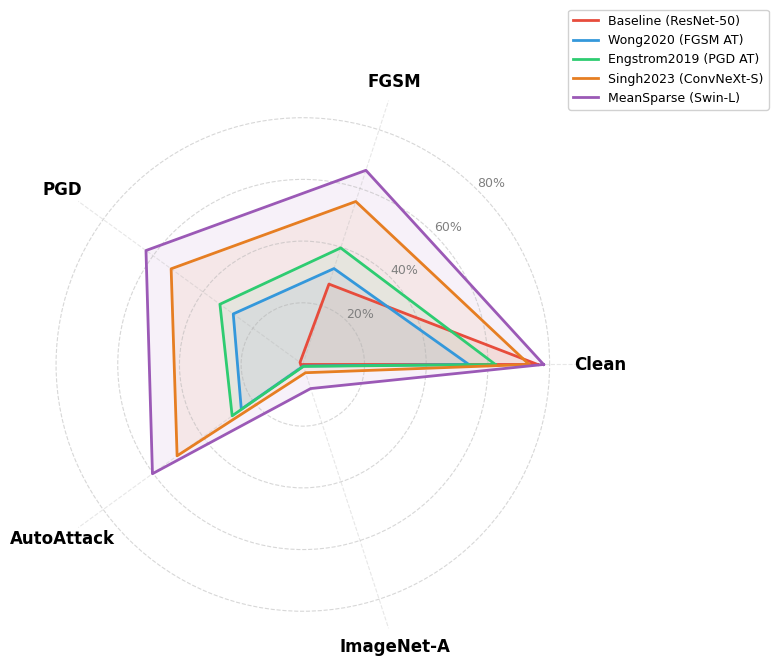

Saved: plot_radar.png


In [12]:
# ── Radar Plot ────────────────────────────────────────────────────────────────
model_labels = [
    'Baseline (ResNet-50)',
    'Wong2020 (FGSM AT)',
    'Engstrom2019 (PGD AT)',
    'Singh2023 (ConvNeXt-S)',
    'MeanSparse (Swin-L)',
]

condition_labels = [
    'Clean',
    'FGSM',
    'PGD',
    'AutoAttack',
    'ImageNet-A',
]

key_matrix = [
    ['standard_clean_acc', 'standard_fgsm_acc', 'standard_pgd_acc', 'standard_autoattack_acc', 'standard_imagenet_a_acc'],
    ['fgsm_clean_acc',     'fgsm_fgsm_acc',     'fgsm_pgd_acc',     'fgsm_autoattack_acc',     'fgsm_imagenet_a_acc'],
    ['pgd_clean_acc',      'pgd_fgsm_acc',       'pgd_pgd_acc',      'pgd_autoattack_acc',      'pgd_imagenet_a_acc'],
    ['singh_clean_acc',    'singh_fgsm_acc',     'singh_pgd_acc',    'singh_autoattack_acc',    'singh_imagenet_a_acc'],
    ['meansparse_clean_acc','meansparse_fgsm_acc','meansparse_pgd_acc','meansparse_autoattack_acc','meansparse_imagenet_a_acc'],
]

val_matrix = [
    [results.get(k, 0) for k in row]
    for row in key_matrix
]

model_colors = ['#e74c3c', '#3498db', '#2ecc71', '#e67e22', '#9b59b6']

# ── Radar setup ────────────────────────────────────────────────────────────
N = len(condition_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for m_idx, (label, color) in enumerate(zip(model_labels, model_colors)):
    vals = val_matrix[m_idx] + val_matrix[m_idx][:1]
    ax.plot(angles, vals, linewidth=2, linestyle='solid', color=color, label=label)
    ax.fill(angles, vals, alpha=0.08, color=color)

# ── Axes formatting ────────────────────────────────────────────────────────
ax.set_xticks(angles[:-1])
ax.set_xticklabels(condition_labels, fontsize=12, fontweight='bold')
ax.set_ylim(0, 90)
ax.set_yticks([20, 40, 60, 80])
ax.set_yticklabels(['20%', '40%', '60%', '80%'], fontsize=9, color='grey')
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_rlabel_position(45)
ax.spines['polar'].set_visible(False)

ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
          fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('plot_radar.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: plot_radar.png")

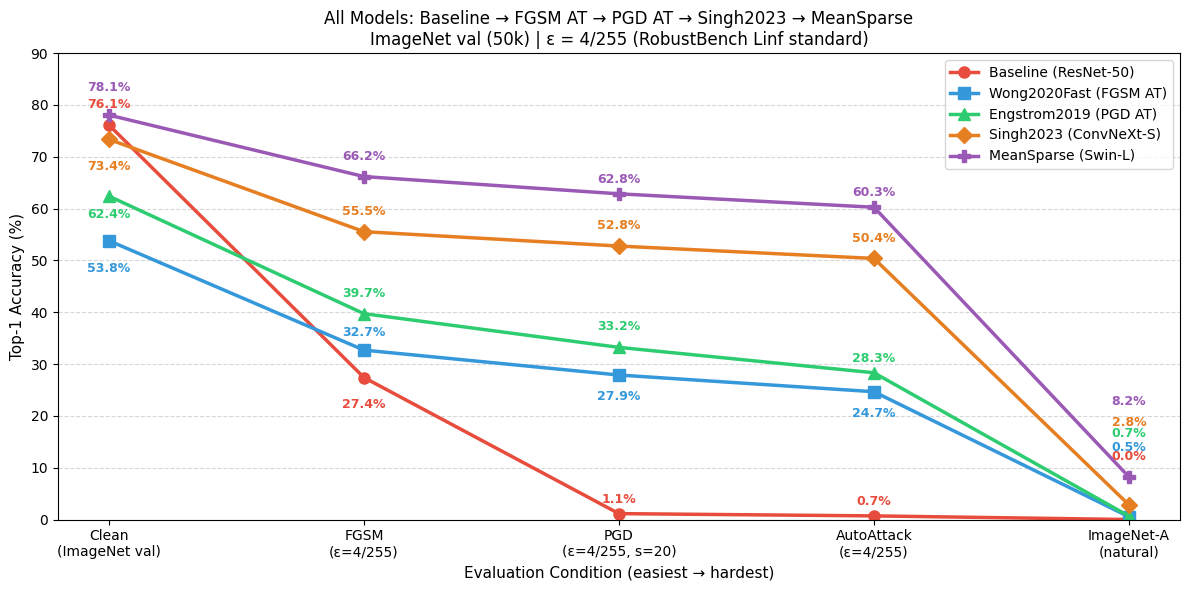

Saved: plot_all_five_models.png


In [8]:
# ── Line Plot: All Models × All Conditions ────────────────────────────────────
conditions = [
    'Clean\n(ImageNet val)',
    'FGSM\n(ε=4/255)',
    'PGD\n(ε=4/255, s=20)',
    'AutoAttack\n(ε=4/255)',
    'ImageNet-A\n(natural)',
]

models = [
    {
        'label': 'Baseline (ResNet-50)',
        'keys':  ['standard_clean_acc', 'standard_fgsm_acc', 'standard_pgd_acc',
                  'standard_autoattack_acc', 'standard_imagenet_a_acc'],
        'color':  '#e74c3c',
        'marker': 'o',
    },
    {
        'label': 'Wong2020Fast (FGSM AT)',
        'keys':  ['fgsm_clean_acc', 'fgsm_fgsm_acc', 'fgsm_pgd_acc',
                  'fgsm_autoattack_acc', 'fgsm_imagenet_a_acc'],
        'color':  '#3498db',
        'marker': 's',
    },
    {
        'label': 'Engstrom2019 (PGD AT)',
        'keys':  ['pgd_clean_acc', 'pgd_fgsm_acc', 'pgd_pgd_acc',
                  'pgd_autoattack_acc', 'pgd_imagenet_a_acc'],
        'color':  '#2ecc71',
        'marker': '^',
    },
    {
        'label': 'Singh2023 (ConvNeXt-S)',
        'keys':  ['singh_clean_acc', 'singh_fgsm_acc', 'singh_pgd_acc',
                  'singh_autoattack_acc', 'singh_imagenet_a_acc'],
        'color':  '#e67e22',
        'marker': 'D',
    },
    {
        'label': 'MeanSparse (Swin-L)',
        'keys':  ['meansparse_clean_acc', 'meansparse_fgsm_acc', 'meansparse_pgd_acc',
                  'meansparse_autoattack_acc', 'meansparse_imagenet_a_acc'],
        'color':  '#9b59b6',
        'marker': 'P',
    },
]

label_offsets = {
    '#e74c3c': {  # Baseline
        0: (0,  10, 'bottom'),
        1: (0, -15, 'top'),
        2: (0,  15, 'top'),
        3: (0,  15, 'top'),
        4: (0,  50, 'top'),
    },
    '#3498db': {  # Wong2020
        0: (0, -15, 'top'),
        1: (0,   8, 'bottom'),
        2: (0, -20, 'bottom'),
        3: (0, -20, 'bottom'),
        4: (0,  45, 'bottom'),
    },
    '#2ecc71': {  # Engstrom2019
        0: (0, -18, 'bottom'),
        1: (0,  10, 'bottom'),
        2: (0,  10, 'bottom'),
        3: (0,  15, 'top'),
        4: (0,  55, 'bottom'),
    },
    '#e67e22': {  # Singh2023
        0: (0, -15, 'top'),
        1: (0,  10, 'bottom'),
        2: (0,  10, 'bottom'),
        3: (0,  10, 'bottom'),
        4: (0,  55, 'bottom'),
    },
    '#9b59b6': {  # MeanSparse
        0: (0,  15, 'bottom'),
        1: (0,  10, 'bottom'),
        2: (0, 15, 'top'),
        3: (0, 15, 'top'),
        4: (0,  50, 'bottom'),
    },
}


x = np.arange(len(conditions))

fig, ax = plt.subplots(figsize=(12, 6))

for m in models:
    vals   = [results.get(k, None) for k in m['keys']]
    x_plot = [x[i] for i, v in enumerate(vals) if v is not None]
    y_plot = [v     for v in vals               if v is not None]

    ax.plot(x_plot, y_plot,
            marker=m['marker'], linewidth=2.5, markersize=8,
            label=m['label'], color=m['color'])

    offsets = label_offsets[m['color']]
    for idx, (xi, yi) in enumerate(zip(x_plot, y_plot)):
        xo, yo, va = offsets[idx]
        ax.annotate(f'{yi:.1f}%',
                    xy=(xi, yi),
                    xytext=(xo, yo),
                    textcoords='offset points',
                    ha='center', va=va,
                    fontsize=9, color=m['color'], fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=10)
ax.set_xlabel('Evaluation Condition (easiest → hardest)', fontsize=11)
ax.set_ylabel('Top-1 Accuracy (%)', fontsize=11)
ax.set_title('All Models: Baseline → FGSM AT → PGD AT → Singh2023 → MeanSparse\n'
             'ImageNet val (50k) | ε = 4/255 (RobustBench Linf standard)',
             fontsize=12)


ax.set_ylim(0, 90)
ax.legend(fontsize=10, loc='upper right')
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('plot_all_five_models.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: plot_all_five_models.png")

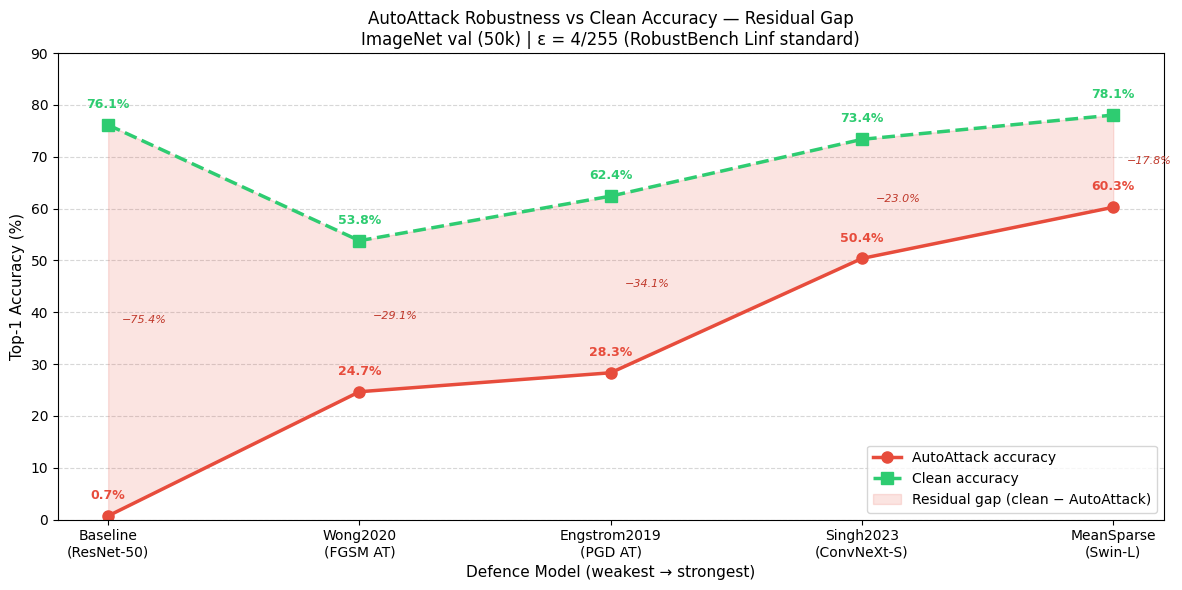

Saved: plot_autoattack_residual.png


In [43]:
# ── Residual Gap Plot: Clean vs AutoAttack ────────────────────────────────────
models_x = [
    'Baseline\n(ResNet-50)',
    'Wong2020\n(FGSM AT)',
    'Engstrom2019\n(PGD AT)',
    'Singh2023\n(ConvNeXt-S)',
    'MeanSparse\n(Swin-L)',
]

clean_keys = ['standard_clean_acc', 'fgsm_clean_acc', 'pgd_clean_acc',
              'singh_clean_acc', 'meansparse_clean_acc']
aa_keys    = ['standard_autoattack_acc', 'fgsm_autoattack_acc', 'pgd_autoattack_acc',
              'singh_autoattack_acc', 'meansparse_autoattack_acc']

clean_vals = [results.get(k, None) for k in clean_keys]
aa_vals    = [results.get(k, None) for k in aa_keys]
residual   = [c - a if c is not None and a is not None else None
              for c, a in zip(clean_vals, aa_vals)]

x = np.arange(len(models_x))

fig, ax = plt.subplots(figsize=(12, 6))

# ── AutoAttack line ────────────────────────────────────────────────────────
ax.plot(x, aa_vals, marker='o', linewidth=2.5, markersize=8,
        color='#e74c3c', label='AutoAttack accuracy')
for xi, yi in zip(x, aa_vals):
    ax.annotate(f'{yi:.1f}%', xy=(xi, yi), xytext=(0, 10),
                textcoords='offset points', ha='center', va='bottom',
                fontsize=9, color='#e74c3c', fontweight='bold')

# ── Clean line ─────────────────────────────────────────────────────────────
ax.plot(x, clean_vals, marker='s', linewidth=2.5, markersize=8,
        color='#2ecc71', label='Clean accuracy', linestyle='--')
for xi, yi in zip(x, clean_vals):
    ax.annotate(f'{yi:.1f}%', xy=(xi, yi), xytext=(0, 10),
                textcoords='offset points', ha='center', va='bottom',
                fontsize=9, color='#2ecc71', fontweight='bold')

# ── Residual shading between clean and AutoAttack ─────────────────────────
ax.fill_between(x,
                [a for a in aa_vals],
                [c for c in clean_vals],
                alpha=0.15, color='#e74c3c',
                label='Residual gap (clean − AutoAttack)')

# ── Residual value annotations at midpoint ────────────────────────────────
for xi, res, aa, cl in zip(x, residual, aa_vals, clean_vals):
    mid = (aa + cl) / 2
    ax.annotate(f'−{res:.1f}%',
                xy=(xi, mid), xytext=(10, 0),
                textcoords='offset points',
                ha='left', va='center',
                fontsize=8, color='#c0392b', fontstyle='italic')

ax.set_xticks(x)
ax.set_xticklabels(models_x, fontsize=10)
ax.set_xlabel('Defence Model (weakest → strongest)', fontsize=11)
ax.set_ylabel('Top-1 Accuracy (%)', fontsize=11)
ax.set_title('AutoAttack Robustness vs Clean Accuracy — Residual Gap\n'
             'ImageNet val (50k) | ε = 4/255 (RobustBench Linf standard)',
             fontsize=12)
ax.set_ylim(0, 90)
ax.legend(fontsize=10, loc='lower right')
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('plot_autoattack_residual.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: plot_autoattack_residual.png")